# Question 2 : K-Means Implementation

In [443]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import hashlib

# For debugging purposes, not used in final implementation
from sklearn.cluster import KMeans as SklearnKMeans
import warnings
warnings.filterwarnings("ignore")

In [444]:
def print_separator():
    print("\n" + "="*50 + "\n")

In [445]:
class KMeans:
    """
    Custom K-Means Clustering implementation
    """
    
    def __init__(self, k, max_iters=100, seed=42):
        """
        Initialize K-Means clustering
        
        Parameters:
        k (int): Number of clusters
        max_iters (int): Maximum number of iterations
        seed (int): Random seed for reproducibility
        """
        self.k = k
        self.max_iters = max_iters
        self.random_state = seed
        
    def fit(self, X):
        """
        Train the K-Means model by using K clusters on the dataset
        
        Parameters:
        X (array-like): Training data
        """
        np.random.seed(self.random_state)
        self.X = X
        self.n_samples, self.n_features = X.shape
        
        # Initialize centroids randomly from the data points
        self.centroids = X[np.random.choice(self.n_samples, self.k, replace=False)]
        self._init_centroids_plus_plus()

        # print_separator()
        # print(self.centroids.shape)
        # Store history for convergence analysis
        self.centroid_history = [self.centroids.copy()]
        
        for i in range(self.max_iters):
            # Assign points to clusters
            self.labels = self._assign_clusters()
            
            # Update centroids
            new_centroids = self._update_centroids()
            
            # Check for convergence
            if np.allclose(self.centroids, new_centroids):
                break
                
            self.centroids = new_centroids
            self.centroid_history.append(self.centroids.copy())

    def _init_centroids_plus_plus(self):
        """
        Initialize centroids using K-Means++ algorithm for better initialization
        """
        self.centroids = np.zeros((self.k, self.n_features))

        # Choose first centroid randomly
        self.centroids[0] = self.X[np.random.randint(0, self.n_samples)]
        
        # Choose remaining centroids
        for i in range(1, self.k):
            # Calculate squared distances to nearest existing centroid
            distances = np.array([min([np.sum((x - c)**2) for c in self.centroids[:i]]) for x in self.X])
            
            # Choose next centroid with probability proportional to squared distance
            probabilities = distances / distances.sum()
            cumulative_probs = probabilities.cumsum()
            r = np.random.rand()
            
            for j, prob in enumerate(cumulative_probs):
                if r < prob:
                    self.centroids[i] = self.X[j]
                    break
    
    def _assign_clusters(self):
        """
        Assign each data point to the nearest centroid
        Returns:
        array: Cluster labels for each data point, of size n_samples
        """
        distances = np.sqrt(((self.X - self.centroids[:, np.newaxis])**2).sum(axis=2))

        # The concept of Broadcasting is used here
        # print(self.X.shape, self.centroids.shape, self.centroids[:, np.newaxis].shape, distances.shape)
        # print((self.X - self.centroids[:, np.newaxis]).shape)

        return np.argmin(distances, axis=0)
    
    def _update_centroids(self):
        """
        Update centroids based on current cluster assignments
        Returns:
        array: Updated centroids of shape (k, n_features)
        """
        centroids = np.zeros((self.k, self.n_features))
        for k in range(self.k):
            if np.sum(self.labels == k) > 0:
                centroids[k] = self.X[self.labels == k].mean(axis=0)
            else:
                # If no points assigned to cluster, keep old centroid
                centroids[k] = self.centroids[k]
        return centroids
    
    def predict(self, X):
        """
        Assign a cluster number to each data-point based on the centroids 
        obtained from the fit() function
        
        Parameters:
        X (array-like): Data points to predict
        
        Returns:
        array: Cluster labels for each data point
        """
        distances = np.sqrt(((X - self.centroids[:, np.newaxis])**2).sum(axis=2))
        return np.argmin(distances, axis=0)
    
    def getCost(self):
        """
        Return the cost of K-Means, i.e., the Within-Cluster Sum of Squares (WCSS)
        
        Returns:
        float: WCSS value
        """
        wcss = 0
        for k in range(self.k):
            cluster_points = self.X[self.labels == k]
            if len(cluster_points) > 0:
                wcss += np.sum((cluster_points - self.centroids[k])**2)
        return wcss

In [446]:
def _add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

In [447]:
def load_and_preprocess_data(df : pd.DataFrame, seed : int) -> pd.DataFrame:
    """
    Load and preprocess the customer dataset
    Parameters:
    df (DataFrame): Input dataframe containing the dataset
    seed (int): Random seed for reproducibility
    Returns:
    df (DataFrame): Preprocessed dataframe
    """

    # Display basic information about the dataset
    print("Dataset Info:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nData types:")
    print(df.dtypes)
    print("\nFirst few rows:")
    print(df.head())

    # Check for missing values
    print("\nMissing values:")
    missing_values = df.isnull().sum()
    print(missing_values)

    if missing_values.sum() > 0:
        print("\nHandling missing values...")
        
        # Handle Gender column probabilistically (stratified approach)
        if df['Genre'].isnull().any():
            # Calculate the proportion of each gender in the non-missing data
            gender_proportions = df['Genre'].value_counts(normalize=True)
            
            # Fill missing gender values probabilistically
            missing_gender_count = df['Genre'].isnull().sum()
            if missing_gender_count > 0:
                np.random.seed(seed)  # For reproducibility
                random_genders = np.random.choice(
                    gender_proportions.index, 
                    size=missing_gender_count, 
                    p=gender_proportions.values
                )
                df.loc[df['Genre'].isnull(), 'Genre'] = random_genders
        
        # Fill numerical columns with median values
        numerical_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
        for col in numerical_columns:
            if df[col].isnull().any():
                median_value = df[col].median()
                df[col].fillna(median_value, inplace=True)
                print(f"Filled {col} missing values with median: {median_value}")

    # Box plots to identify outliers
    print("\nPlotting box plots to identify outliers...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Box Plots for Outlier Detection', fontsize=16)

    numerical_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
    colors = ['skyblue', 'lightgreen', 'salmon']

    for i, col in enumerate(numerical_columns):
        axes[i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.7))
        axes[i].set_title(f'{col} Box Plot')
        axes[i].set_ylabel(col)
        _add_username("siddarth.g")

    plt.tight_layout()
    plt.show()

    # Detect and handle outliers using IQR method
    # print("\nDetecting and handling outliers...")
    # for col in numerical_columns:
    #     Q1 = df[col].quantile(0.25)
    #     Q3 = df[col].quantile(0.75)
    #     IQR = Q3 - Q1
        
    #     # Define outlier bounds
    #     lower_bound = Q1 - 1.5 * IQR
    #     upper_bound = Q3 + 1.5 * IQR
        
    #     # Identify outliers
    #     outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
    #     if len(outliers) > 0:
    #         print(f"\n{col}: Found {len(outliers)} outliers")
    #         print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
            
    #         # Replace outliers with median
    #         median_value = df[col].median()
    #         df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = median_value
    #         print(f"Replaced outliers with median: {median_value}")
    #     else:
    #         print(f"\n{col}: No outliers detected")

    return df

In [448]:
def elbow_method(X, max_k=10, seed=42, max_it=100, use_custom=True):
    """
    Implement Elbow Method to find optimal number of clusters
    
    Parameters:
    X (array): Preprocessed data
    max_k (int): Maximum number of clusters to test
    seed (int): Random value seed
    max_it (int): Maximum iteration steps
    use_custom (bool): True to use custom KMeans, False to use sklearn
    
    Returns:
    list: WCSS values for each k
    """
    wcss_values = []
    k_range = range(1, max_k + 1)
    
    print(f"Computing WCSS using {'Custom KMeans' if use_custom else 'Sklearn KMeans'} implementation...")
    
    for k in k_range:
        print(f"  k={k}...", end=" ")
        
        if use_custom:
            # Use custom KMeans implementation
            kmeans = KMeans(k=k, seed=seed, max_iters=max_it)
            kmeans.fit(X)
            wcss = kmeans.getCost()
        else:
            # Use sklearn KMeans implementation
            kmeans = SklearnKMeans(n_clusters=k, random_state=seed, max_iter=max_it, n_init=10)
            kmeans.fit(X)
            wcss = kmeans.inertia_
        
        wcss_values.append(wcss)
        print(f"WCSS: {wcss:.2f}")
    
    # Plot WCSS vs k
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss_values, 'bo-', linewidth=2, markersize=8)
    plt.title(f'Elbow Method for Optimal k ({'Custom' if use_custom else 'Sklearn'} Implementation)', fontsize=14)
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(k_range)
    plt.tight_layout()
    _add_username("siddarth.g")
    plt.show()
    
    # Calculate elbow point (simplified method)
    # Look for the point where the rate of decrease sharply changes
    differences = np.diff(wcss_values)
    second_differences = np.diff(differences)
    elbow_point = np.argmax(second_differences) + 2  # +2 because of double diff
    
    print(f"\nElbow Method Results:")
    print(f"WCSS values: {[f'{wcss:.2f}' for wcss in wcss_values]}")
    print(f"Suggested optimal k (elbow point): {elbow_point}")
    print(f"Using {'Custom KMeans' if use_custom else 'Sklearn KMeans'} implementation")
    
    return wcss_values, elbow_point

In [449]:
def silhouette_method(X, max_k=10, seed=42, max_it=100, use_custom=True):
    """
    Implement Silhouette Method to find optimal number of clusters
    
    Parameters:
    X (array): Preprocessed data
    max_k (int): Maximum number of clusters to test
    seed (int): Random seed for reproducibility
    max_it (int): Maximum iteration steps
    use_custom (bool): True to use custom KMeans, False to use sklearn
    
    Returns:
    list: Silhouette scores for each k
    """
    silhouette_scores = []
    k_range = range(2, max_k + 1)  # Silhouette requires at least 2 clusters
    
    print(f"Computing Silhouette scores using {'Custom KMeans' if use_custom else 'Sklearn KMeans'} implementation...")
    
    for k in k_range:
        print(f"  k={k}...", end=" ")
        
        if use_custom:
            # Use custom KMeans implementation
            kmeans = KMeans(k=k, seed=seed, max_iters=max_it)
            kmeans.fit(X)
            labels = kmeans.predict(X)
        else:
            # Use sklearn KMeans implementation
            kmeans = SklearnKMeans(n_clusters=k, random_state=seed, max_iter=max_it, n_init=10)
            kmeans.fit(X)
            labels = kmeans.labels_
        
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        print(f"Score: {score:.4f}")
    
    # Plot silhouette scores vs k
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
    plt.title(f'Silhouette Method for Optimal k ({'Custom' if use_custom else 'Sklearn'} Implementation)', fontsize=14)
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Average Silhouette Score', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(k_range)
    plt.tight_layout()
    _add_username("siddarth.g")
    plt.show()
    
    # Find k with maximum silhouette score
    optimal_k = k_range[np.argmax(silhouette_scores)]
    
    print(f"\nSilhouette Method Results:")
    print(f"Silhouette scores: {dict(zip(k_range, [f'{score:.4f}' for score in silhouette_scores]))}")
    print(f"Optimal k (maximum silhouette score): {optimal_k}")
    print(f"Maximum silhouette score: {max(silhouette_scores):.4f}")
    print(f"Using {'Custom KMeans' if use_custom else 'Sklearn KMeans'} implementation")
    
    return silhouette_scores, optimal_k

In [450]:
def combined_optimal_k_method(X, max_k=10, seed=42, max_it=100, use_custom=True):
    """
    Combined Elbow and Silhouette Method to find optimal number of clusters
    Trains each model only once and computes both WCSS and silhouette scores
    
    Parameters:
    X (array): Preprocessed data
    max_k (int): Maximum number of clusters to test
    seed (int): Random seed for reproducibility
    max_it (int): Maximum iteration steps
    use_custom (bool): True to use custom KMeans, False to use sklearn
    
    Returns:
    tuple: (wcss_values, silhouette_scores, elbow_k, silhouette_k)
    """
    wcss_values = []
    silhouette_scores = []
    k_range_wcss = range(1, max_k + 1)
    k_range_silhouette = range(2, max_k + 1)  # Silhouette requires at least 2 clusters
    
    print(f"Computing WCSS and Silhouette scores using {'Custom KMeans' if use_custom else 'Sklearn KMeans'} implementation...")
    print("This combined approach trains each model only once per k value.\n")
    
    for k in k_range_wcss:
        print(f"  k={k}...", end=" ")
        
        if use_custom:
            # Use custom KMeans implementation
            kmeans = KMeans(k=k, seed=seed, max_iters=max_it)
            kmeans.fit(X)
            wcss = kmeans.getCost()
            labels = kmeans.predict(X)
        else:
            # Use sklearn KMeans implementation
            kmeans = SklearnKMeans(n_clusters=k, random_state=seed, max_iter=max_it, n_init=10)
            kmeans.fit(X)
            wcss = kmeans.inertia_
            labels = kmeans.labels_
        
        wcss_values.append(wcss)
        
        # Calculate silhouette score only for k >= 2
        if k >= 2:
            score = silhouette_score(X, labels)
            silhouette_scores.append(score)
            print(f"WCSS: {wcss:.2f}, Silhouette: {score:.4f}")
        else:
            print(f"WCSS: {wcss:.2f}, Silhouette: N/A (k=1)")
    
    # Plot WCSS vs k (Elbow Method)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Elbow plot
    ax1.plot(k_range_wcss, wcss_values, 'bo-', linewidth=2, markersize=8)
    ax1.set_title(f'Elbow Method for Optimal k ({'Custom' if use_custom else 'Sklearn'} Implementation)', fontsize=14)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(k_range_wcss)
    
    # Silhouette plot
    ax2.plot(k_range_silhouette, silhouette_scores, 'ro-', linewidth=2, markersize=8)
    ax2.set_title(f'Silhouette Method for Optimal k ({'Custom' if use_custom else 'Sklearn'} Implementation)', fontsize=14)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax2.set_ylabel('Average Silhouette Score', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(k_range_silhouette)
    
    _add_username("siddarth.g")
    
    plt.tight_layout()
    plt.show()
    
    # Calculate elbow point (simplified method)
    differences = np.diff(wcss_values)
    second_differences = np.diff(differences)
    elbow_point = np.argmax(second_differences) + 2  # +2 because of double diff
    
    # Find k with maximum silhouette score
    optimal_k_silhouette = k_range_silhouette[np.argmax(silhouette_scores)]
    
    print(f"\nCombined Method Results:")
    print(f"WCSS values: {[f'{wcss:.2f}' for wcss in wcss_values]}")
    print(f"Silhouette scores: {dict(zip(k_range_silhouette, [f'{score:.4f}' for score in silhouette_scores]))}")
    print(f"Suggested optimal k (elbow point): {elbow_point}")
    print(f"Optimal k (maximum silhouette score): {optimal_k_silhouette}")
    print(f"Maximum silhouette score: {max(silhouette_scores):.4f}")
    print(f"Using {'Custom KMeans' if use_custom else 'Sklearn KMeans'} implementation")
    
    return wcss_values, silhouette_scores, elbow_point, optimal_k_silhouette

In [451]:
def visualize_clusters(X, labels, centroids, title="K-Means Clustering Results"):
    """
    Visualize clustering results (2D projection using last two features)
    """
    plt.figure(figsize=(12, 8))
    
    # Create scatter plot with different colors for each cluster
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'teal', 'navy', 'maroon', 'lime', 'coral', 'gold', 'darkgreen', 'darkblue']
    
    for i in range(len(np.unique(labels))):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            plt.scatter(cluster_points[:, 1], cluster_points[:, 2], c=colors[i % len(colors)], label=f'Cluster {i+1}', alpha=0.7)
    
    # Plot centroids
    plt.scatter(centroids[:, 1], centroids[:, 2], 
               c='black', marker='x', s=200, linewidths=3, label='Centroids')
    
    plt.title(title, fontsize=14)
    plt.xlabel('Annual Income (standardized)', fontsize=12)
    plt.ylabel('Spending Score (standardized)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    _add_username("siddarth.g")
    plt.show()

In [452]:
print_separator()
print("K-MEANS CLUSTERING IMPLEMENTATION AND ANALYSIS")
print_separator()



K-MEANS CLUSTERING IMPLEMENTATION AND ANALYSIS




In [453]:
username = "siddarth.g"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
print("Seed value : ", seed)
print_separator()
# seed = 42

global_flag = True  # Set to True to use custom KMeans implementation, False for sklearn implementation

Seed value :  2198587646





1. LOADING AND PREPROCESSING DATA


Dataset Info:
Shape: (200, 5)
Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                  int64
Genre                      object
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

First few rows:
   CustomerID   Genre   Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male  19.0                15.0                    39.0
1           2    Male  21.0                 NaN                    81.0
2           3  Female  20.0                16.0                     6.0
3           4  Female  23.0                16.0                    77.0
4           5  Female  31.0                17.0                    40.0

Missing values:
CustomerID                0
Genre                     6
Age                       6
Annual Income (k$)        6
Spending Score (1-100)    6
dtype: int64

Handling missing values...
F

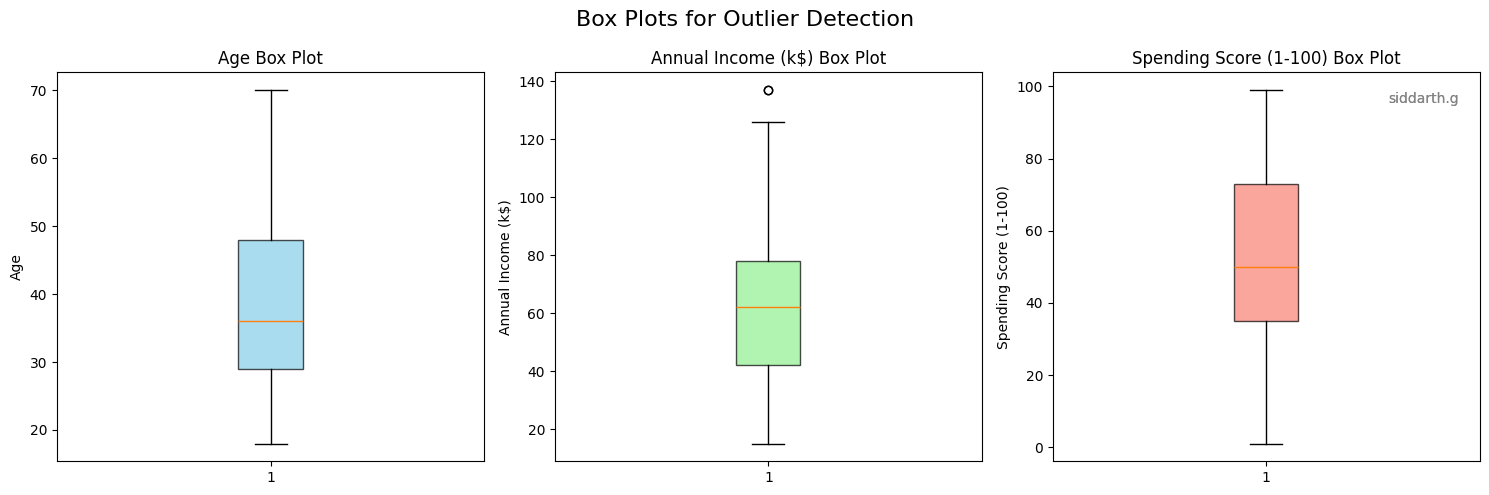

In [454]:
# Load and preprocess data
print("\n1. LOADING AND PREPROCESSING DATA")
print_separator()
df = pd.read_csv('data/Q2_Clustering_dataset.csv')
df = load_and_preprocess_data(df, seed)


In [455]:
# Z-scale normalize the columns and one-hot encode categorical variables

feature_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_raw = df[feature_columns].values

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Append one-hot encoded columns for 'Genre'
# encoder = OneHotEncoder()
# X_genre = encoder.fit_transform(df[['Genre']])
# X = np.hstack((X_genre.toarray(), X))

print(f"Data shape after preprocessing: {X.shape}")
print("First few rows of preprocessed data:")
print(X[:5])

Data shape after preprocessing: (200, 3)
First few rows of preprocessed data:
[[-1.42602061 -1.76824502 -0.44100336]
 [-1.28087856  0.04435075  1.19234243]
 [-1.35344959 -1.72967915 -1.72434649]
 [-1.13573652 -1.72967915  1.03678569]
 [-0.55516833 -1.69111328 -0.40211418]]



2. DETERMINING OPTIMAL NUMBER OF CLUSTERS



2.1 Combined Elbow and Silhouette Method:
Computing WCSS and Silhouette scores using Custom KMeans implementation...
This combined approach trains each model only once per k value.

  k=1... WCSS: 600.00, Silhouette: N/A (k=1)
  k=2... WCSS: 392.17, Silhouette: 0.3278
  k=3... WCSS: 303.70, Silhouette: 0.3383
  k=4... WCSS: 258.15, Silhouette: 0.3446
  k=5... WCSS: 174.13, Silhouette: 0.4038
  k=6... WCSS: 162.91, Silhouette: 0.3566
  k=7... WCSS: 148.52, Silhouette: 0.3392
  k=8... WCSS: 127.95, Silhouette: 0.3409
  k=9... WCSS: 124.68, Silhouette: 0.3208
  k=10... WCSS: 113.16, Silhouette: 0.3282


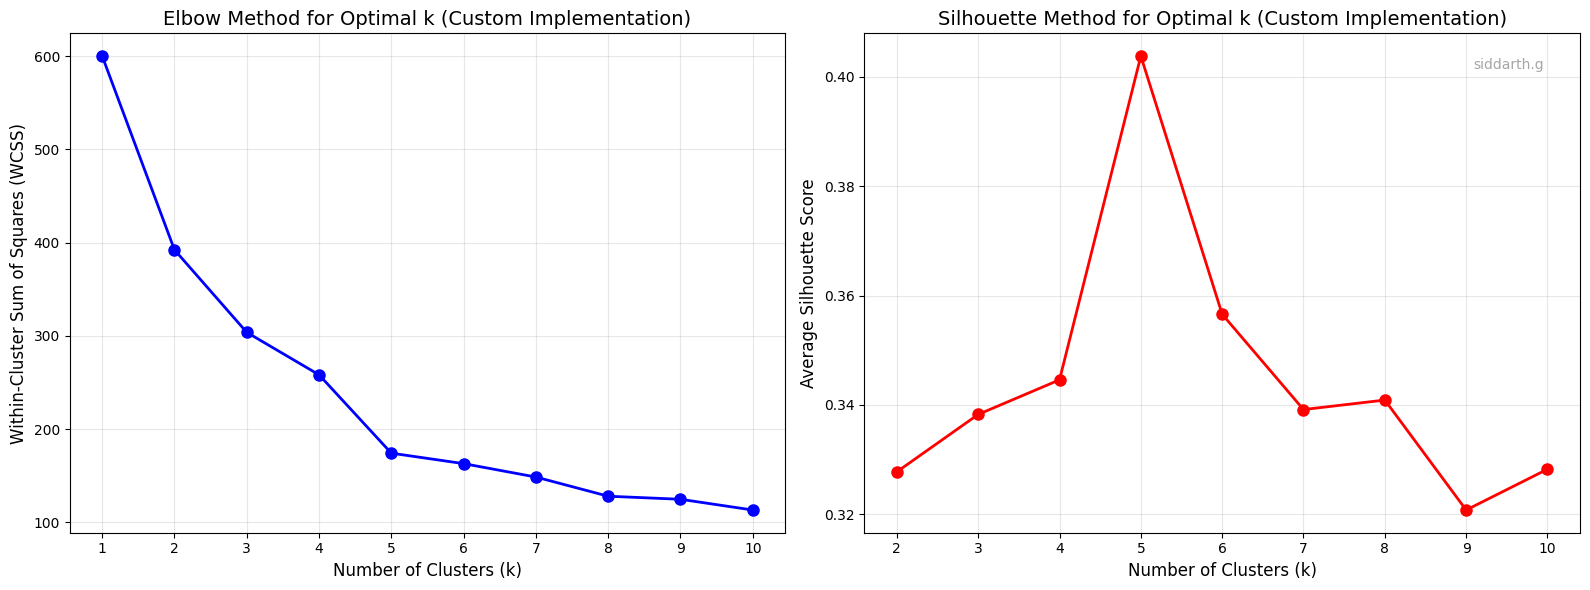


Combined Method Results:
WCSS values: ['600.00', '392.17', '303.70', '258.15', '174.13', '162.91', '148.52', '127.95', '124.68', '113.16']
Silhouette scores: {2: '0.3278', 3: '0.3383', 4: '0.3446', 5: '0.4038', 6: '0.3566', 7: '0.3392', 8: '0.3409', 9: '0.3208', 10: '0.3282'}
Suggested optimal k (elbow point): 2
Optimal k (maximum silhouette score): 5
Maximum silhouette score: 0.4038
Using Custom KMeans implementation


In [456]:
# Determine optimal number of clusters
print("\n2. DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print_separator()

# Combined Elbow and Silhouette Method (trains each model only once)
print("\n2.1 Combined Elbow and Silhouette Method:")
wcss_values, silhouette_scores, elbow_k, silhouette_k = combined_optimal_k_method(X, max_k=10, seed=seed, max_it=1000, use_custom=global_flag)

# Also run individual methods for comparison (keeping original results and plots)
# print("\n2.2 Individual Elbow Method (for comparison):")
# wcss_values_individual, elbow_k_individual = elbow_method(X, max_k=25, seed=seed, max_it=1000, use_custom=global_flag)

# print("\n2.3 Individual Silhouette Method (for comparison):")
# silhouette_scores_individual, silhouette_k_individual = silhouette_method(X, max_k=25, seed=seed, max_it=1000, use_custom=global_flag)

In [457]:
# Choose optimal k (let's use silhouette method result)
optimal_k = silhouette_k
print(f"\n*** CHOSEN OPTIMAL K: {optimal_k} ***")

# Fit final K-Means model with optimal k
print(f"\n3. FITTING K-MEANS WITH k={optimal_k}")
print_separator()

if global_flag:
    # Use custom KMeans implementation
    print("Using Custom KMeans Implementation")
    final_kmeans = KMeans(k=optimal_k)
    final_kmeans.fit(X)
    final_labels = final_kmeans.predict(X)
    final_cost = final_kmeans.getCost()
    final_centroids = final_kmeans.centroids
else:
    # Use sklearn KMeans implementation
    print("Using Sklearn KMeans Implementation")
    final_kmeans = SklearnKMeans(n_clusters=optimal_k, random_state=seed, n_init=10)
    final_kmeans.fit(X)
    final_labels = final_kmeans.labels_
    final_cost = final_kmeans.inertia_
    final_centroids = final_kmeans.cluster_centers_

print(f"Final WCSS: {final_cost:.4f}")
print(f"Final Silhouette Score: {silhouette_score(X, final_labels):.4f}")
print(f"Implementation used: {'Custom' if global_flag else 'Sklearn'}")


*** CHOSEN OPTIMAL K: 5 ***

3. FITTING K-MEANS WITH k=5


Using Custom KMeans Implementation
Final WCSS: 175.8528
Final Silhouette Score: 0.3921
Implementation used: Custom



4. VISUALIZING CLUSTERS WITH k=5




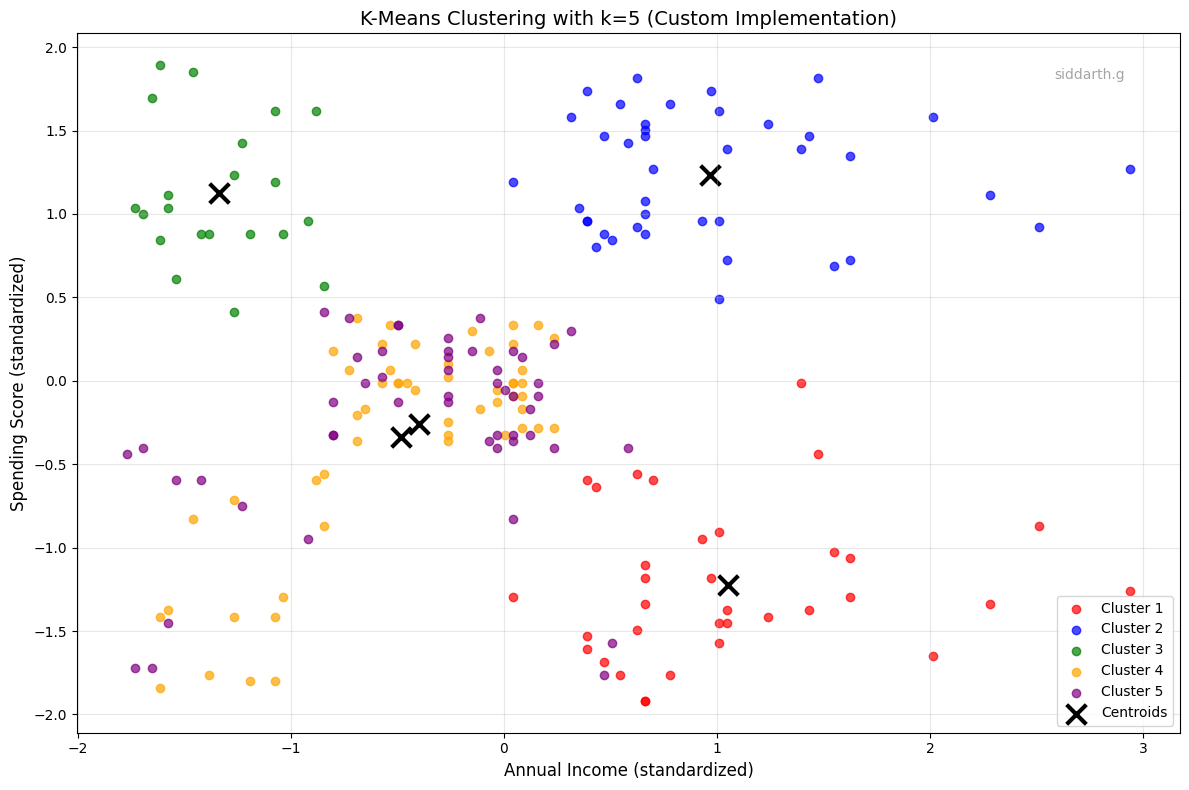

In [458]:
print(f"\n4. VISUALIZING CLUSTERS WITH k={optimal_k}")
print_separator()

visualize_clusters(X, final_labels, final_centroids, title=f"K-Means Clustering with k={optimal_k} ({'Custom' if global_flag else 'Sklearn'} Implementation)")

In [459]:
print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)


ANALYSIS COMPLETE
